[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jibby2k1/SPS_Curriculum/blob/main/Intro_DL_4_Physics/intro_pytorch.ipynb)

**Content Produced by UF Signal Processing Society**

**Authors: Awwab Azam**

Credit: ~~I have used the official PyTorch tutorial (https://docs.pytorch.org/tutorials/beginner/basics/intro.html) for part of this workshop~~

# Intro to Deep Learning using PyTorch

This is the second of a planned 3-part series covering the basics of deep learning for applications in Physics and Engineering. In this workshop, we will learn how the self-attention mechanism works and code a transformer model (the architecture underpinning modern LLMs) from scratch. Let's get started!

### Setup

For this tutorial, we will need several Python packages, including PyTorch, NumPy, and MatplotLib. If you are not very tech-savvy, the easiest thing to do would be to open this notebook in Google Colab using the link at the top. Google Colab is an online cloud-based development environment that comes with all these packages preinstalled.

For those who are comfortable working with Python virtual environments and would like to run the code locally, please make sure you have all the packages in the import section installed.

## 0. Getting started

First we need to import the packages that we want to use.

In [1]:
# imports
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

## 1. Generating data

In [2]:
def generate_vector_sorting_data(num_samples, sequence_length, vector_dim):
    """
    Generates a dataset for sorting N-dimensional vectors by their magnitude.

    Args:
        num_samples (int): The number of input-output pairs to generate.
        sequence_length (int): The number of vectors in each sequence.
        vector_dim (int): The dimension of each vector.
    """
    # Generate random vectors. Shape: (num_samples, sequence_length, vector_dim)
    x_np = np.random.rand(num_samples, sequence_length, vector_dim)

    # Calculate the L2 norm (magnitude) for each vector.
    # Shape: (num_samples, sequence_length)
    magnitudes = np.linalg.norm(x_np, axis=2)

    # Get the indices that would sort the vectors by their magnitudes.
    # Shape: (num_samples, sequence_length)
    sort_indices = np.argsort(magnitudes, axis=1)

    # Create the sorted target tensor using the calculated indices.
    # This is a form of advanced indexing.
    y_np = np.take_along_axis(x_np, sort_indices[:, :, np.newaxis], axis=1)

    # Convert to PyTorch tensors
    combined_arr = np.stack((x_np, y_np), axis=1)
    data_tensor = torch.from_numpy(combined_arr).float()

    return data_tensor


# testing our function to make sure it works properly
# --- Configuration ---
NUM_SAMPLES = 10000
SEQUENCE_LENGTH = 16  # How many vectors in a sequence
VECTOR_DIM = 3  # Each vector will be 3D (e.g., an [x, y, z] vector)

# Generate the data
dataset = generate_vector_sorting_data(NUM_SAMPLES, SEQUENCE_LENGTH, VECTOR_DIM)

# Print shapes to verify
print(f"Shape of data: {dataset.shape}")

# --- Show a detailed example for one sample ---
print("\n--- Example ---")
sample_idx = 0

# Calculate magnitudes for the example to verify the sorting order
input_magnitudes = np.linalg.norm(dataset[sample_idx][0].numpy(), axis=1)
target_magnitudes = np.linalg.norm(dataset[sample_idx][1].numpy(), axis=1)

print(f"\nUnsorted Input Vectors (first 5 of {SEQUENCE_LENGTH}):")
for i in range(5):
    vec_str = np.array2string(
        dataset[sample_idx, 0, i].numpy(),
        formatter={"float_kind": lambda x: "%.3f" % x},
    )
    print(f"  Vector: {vec_str}, Magnitude: {input_magnitudes[i]:.3f}")

print(f"\nSorted Target Vectors (first 5 of {SEQUENCE_LENGTH}):")
for i in range(5):
    vec_str = np.array2string(
        dataset[sample_idx, 1, i].numpy(),
        formatter={"float_kind": lambda x: "%.3f" % x},
    )
    print(f"  Vector: {vec_str}, Magnitude: {target_magnitudes[i]:.3f}")

# Final check
print(
    "\nIs the target magnitude sequence sorted?",
    np.all(target_magnitudes[:-1] <= target_magnitudes[1:]),
)

Shape of data: torch.Size([10000, 2, 16, 3])

--- Example ---

Unsorted Input Vectors (first 5 of 16):
  Vector: [0.378 0.443 0.037], Magnitude: 0.584
  Vector: [0.845 0.514 0.084], Magnitude: 0.993
  Vector: [0.193 0.401 0.209], Magnitude: 0.491
  Vector: [0.917 0.793 0.316], Magnitude: 1.253
  Vector: [0.364 0.719 0.513], Magnitude: 0.955

Sorted Target Vectors (first 5 of 16):
  Vector: [0.193 0.401 0.209], Magnitude: 0.491
  Vector: [0.097 0.559 0.022], Magnitude: 0.568
  Vector: [0.378 0.443 0.037], Magnitude: 0.584
  Vector: [0.054 0.114 0.651], Magnitude: 0.664
  Vector: [0.341 0.167 0.554], Magnitude: 0.672

Is the target magnitude sequence sorted? True


In [3]:
# standardize our data to have 0 mean and unit variance
def normalize(x, mean, std_dev):
    return (x - mean) / std_dev


def denormalize(x, mean, std_dev):
    return (x * std_dev) + mean


# first normalize the x values
x_mean = dataset[:, 0, ...].mean()
x_std = dataset[:, 0, ...].std()
dataset[:, 0, ...] = normalize(dataset[:, 0, ...], x_mean, x_std)

# first normalize the x values
y_mean = dataset[:, 1, ...].mean()
y_std = dataset[:, 1, ...].std()
dataset[:, 1, ...] = normalize(dataset[:, 1, ...], y_mean, y_std)

In [4]:
# save to disk
torch.save(dataset, "dataset_10K_seq_len_16_vec_dim_3.pt")

In [5]:
# make our Dataset class
class VectorSortingDataset(Dataset):
    def __init__(self, filename: str, indices: Tuple[int, int]):
        # get start and end indices
        start_index = indices[0]
        end_index = indices[1]
        # load dataset and split based on indices
        self.data = torch.load(filename, weights_only=True)[start_index:end_index]

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, index):
        # get input and output sequences
        input = self.data[index][0]
        output = self.data[index][1]
        return input, output

In [6]:
sample_dataset = VectorSortingDataset(
    filename="dataset_10K_seq_len_16_vec_dim_3.pt",
    indices=(0, 10),  # this is just a toy example
)
toy_dataloader = DataLoader(sample_dataset, batch_size=5, shuffle=True)

In [7]:
inputs, outputs = next(iter(toy_dataloader))
print(f"Input batch shape: {inputs.shape}")
print(f"Output batch shape: {outputs.size()}")

Input batch shape: torch.Size([5, 16, 3])
Output batch shape: torch.Size([5, 16, 3])


## 2. Building the Transformer

In [8]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, n, device):
        super().__init__()
        self.n = n
        self.device = device

    def compute_pos_vectors(self, k, embed_dim):
        positional_vector = torch.zeros(embed_dim, device=self.device)
        for i in range(int(embed_dim / 2)):
            denominator = np.power(self.n, (2 * i) / embed_dim)
            positional_vector[2 * i] = np.sin(k / denominator)
            positional_vector[(2 * i) + 1] = np.cos(k / denominator)

        return positional_vector

    def forward(self, tensor):
        # tensor should be of form (batch_size, seq_length, embed_dim)
        batch_size, seq_len, embed_dim = tensor.shape

        positional_encoding_matrix = torch.zeros(
            (seq_len, embed_dim), device=self.device
        )
        for i in range(seq_len):
            positional_encoding_matrix[i] = self.compute_pos_vectors(
                k=i, embed_dim=embed_dim
            )
        pos_embeddings = torch.stack(
            [positional_encoding_matrix for b in range(batch_size)]
        )
        return tensor + pos_embeddings

In [9]:
# VANILLA TRANSFORMER WITH SINUSOIDAL POSITIONAL ENCODINGS

# class to implement a single self-attention head
class AttentionHead(nn.Module):
    def __init__(self, dim_model, kdim):
        super().__init__()
        self.kdim = kdim

        # initialize parameter matrices
        self.W_q = nn.Linear(dim_model, kdim, bias=False)
        self.W_k = nn.Linear(dim_model, kdim, bias=False)
        self.W_v = nn.Linear(dim_model, kdim, bias=False)

    def forward(self, src):
        # Assuming src has shape (batch_size, seq_length, dim_model)
        # get Query, Key, and Value matrices for each sequence
        Q = self.W_q(src)
        K = self.W_k(src)
        V = self.W_v(src)

        # calculate attention scores
        K_T = torch.transpose(K, 1, 2)
        attn_logits = torch.matmul(Q, K_T) / np.sqrt(self.kdim)
        attn_weights = torch.nn.functional.softmax(attn_logits, dim=-1)
        attn_outputs = torch.matmul(attn_weights, V)
        return attn_outputs


# class to implement multi-head self-attention
class SelfAttention(nn.Module):
    def __init__(self, dim_model, num_heads):
        super().__init__()

        # make sure num_heads divides dim_model:
        assert dim_model % num_heads == 0, (
            "Number of heads must divide dimension of model"
        )

        # compute kdim = vdim
        kdim = dim_model // num_heads

        # initialize attention heads
        self.attention_heads = nn.ModuleList(
            [AttentionHead(dim_model, kdim) for _ in range(num_heads)]
        )

        # final linear layer
        self.W_o = nn.Linear(dim_model, dim_model, bias=False)

    def forward(self, src):
        # src should have shape (batch_size, seq_length, dim_model)
        # Pass src through the attention heads
        attn_results = [attn_head(src) for attn_head in self.attention_heads]
        # concatenate results
        attn_results = torch.cat(attn_results, dim=-1)
        # pass through final linear layer
        return self.W_o(attn_results)


class TransformerLayer(nn.Module):
    # initialize neural network layers
    def __init__(self, embed_dim=9, num_heads=1, dim_feedforward=32, dropout=0.1):
        super().__init__()
        self.attention = SelfAttention(embed_dim, num_heads)
        self.MLP = nn.Sequential(
            nn.Linear(embed_dim, dim_feedforward),
            nn.GELU(),
            nn.Linear(dim_feedforward, embed_dim),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, src):
        # run through attention block
        src2 = self.attention(src)
        src = self.norm1(src + self.dropout1(src2))

        # run through multilayer perceptron
        src2 = self.MLP(src)
        src = self.norm2(src + self.dropout2(src2))
        return src


class BasicTransformer(nn.Module):
    # initialize alternating attention/MLP layers
    def __init__(
        self,
        num_layers=1,
        input_dim=10,
        embed_dim=36,
        output_dim=10,
        num_heads=1,
        dim_feedforward=64,
        dropout=0.1,
        device=torch.device("cpu"),
    ):
        super().__init__()
        # we want to embed in a higher-dimensional space
        self.linear1 = nn.Linear(input_dim, embed_dim)
        self.linear2 = nn.Linear(embed_dim, output_dim)

        # dropout for the input embeddings
        self.input_dropout = nn.Dropout(dropout)

        self.pos_encoding = SinusoidalPositionalEncoding(10000, device)
        self.layers = nn.ModuleList(
            [
                TransformerLayer(embed_dim, num_heads, dim_feedforward, dropout)
                for _ in range(num_layers)
            ]
        )
        self.to(device)

    def forward(self, x):
        # project to latent space
        x = self.linear1(x)

        # positional encoding
        x = self.pos_encoding(x)

        # apply first dropout layer
        x = self.input_dropout(x)

        # run through encoder layers
        for layer in self.layers:
            x = layer(x)
        x = self.linear2(x)
        return x

In [10]:
# test it out to make sure everything is working
test_model = BasicTransformer(
    num_layers=3,
    input_dim=16,
    output_dim=32,
    num_heads=4,
    dim_feedforward=64,
    dropout=0.0,
)
x = torch.randn(
    5, 10, 16
)  # note how we can use different sequence lengths w/out changing the model
y = test_model(x)
print(y.shape)

torch.Size([5, 10, 32])


## 3. Training the model

In [11]:
train_cutoff = round(0.8 * NUM_SAMPLES)
print(f"Training cutoff is {train_cutoff}")

# make training and test datasets
train_dataset = VectorSortingDataset(
    "dataset_10K_seq_len_16_vec_dim_3.pt", indices=(0, train_cutoff)
)
test_dataset = VectorSortingDataset(
    "dataset_10K_seq_len_16_vec_dim_3.pt", indices=(train_cutoff, NUM_SAMPLES)
)

Training cutoff is 8000


In [12]:
# wrap datasets in Dataloader objects
test_batch_size = train_batch_size = (
    64  # number of samples per batch (could vary for the last batch)
)
train_dataloader = DataLoader(train_dataset, train_batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, test_batch_size, shuffle=True)

In [13]:
def train_loop(dataloader, model, loss_fn, optimizer):
    training_loss = 0
    num_batches = len(dataloader)

    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        training_loss += loss.item()

    # get average
    training_loss /= num_batches
    print(f"Training Loss: {training_loss}")
    return training_loss


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()

    test_loss /= num_batches
    print(f"Test Loss: {test_loss}\n")
    return test_loss

In [14]:
model = BasicTransformer(
    num_layers=3,
    input_dim=3,
    embed_dim=16,
    output_dim=3,
    num_heads=2,
    dim_feedforward=64,
    dropout=0.0,
)
model.eval()

BasicTransformer(
  (linear1): Linear(in_features=3, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=3, bias=True)
  (input_dropout): Dropout(p=0.0, inplace=False)
  (pos_encoding): SinusoidalPositionalEncoding()
  (layers): ModuleList(
    (0-2): 3 x TransformerLayer(
      (attention): SelfAttention(
        (attention_heads): ModuleList(
          (0-1): 2 x AttentionHead(
            (W_q): Linear(in_features=16, out_features=8, bias=False)
            (W_k): Linear(in_features=16, out_features=8, bias=False)
            (W_v): Linear(in_features=16, out_features=8, bias=False)
          )
        )
        (W_o): Linear(in_features=16, out_features=16, bias=False)
      )
      (MLP): Sequential(
        (0): Linear(in_features=16, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=64, out_features=16, bias=True)
      )
      (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (norm2): Lay

In [15]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

In [ ]:
train_losses = []
test_losses = []

epochs = 100
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train_losses.append(train_loop(train_dataloader, model, loss_fn, optimizer))
    test_losses.append(test_loop(test_dataloader, model, loss_fn))
print("Done!")

Epoch 1
-------------------------------


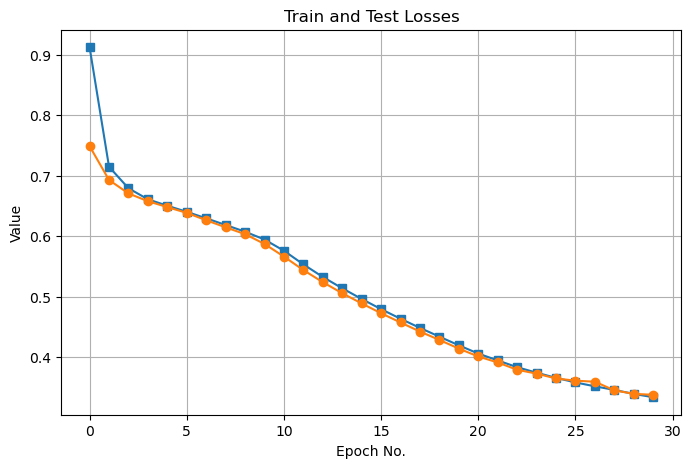

In [17]:
def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, marker="s")  # Plot the list with markers
    plt.plot(test_losses, marker="o")  # Plot the list with markers
    plt.title("Train and Test Losses")
    plt.xlabel("Epoch No.")
    plt.ylabel("Value")
    plt.grid(True)

    # Show the plot
    plt.show()


plot_losses(train_losses, test_losses)

In [18]:
torch.save(model.state_dict(), "transformer_model.pth")